In [1263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option("display.float_format", "{:.3e}".format)

plt.style.use('dark_background')

rs = 1.0
r_photon = 1.5 * rs

DATA_DIR = Path("../results/data")  # adjust if needed

In [1264]:
def load(name):
    path = DATA_DIR / name
    df = pd.read_csv(path)
    return df

In [1265]:
def plot_traj(df, ax=None, label=None, color="yellow"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,8))

    phi = df["phi"]
    x = df["r"] * np.cos(phi)
    y = df["r"] * np.sin(phi)

    ax.plot(x, y, color=color, label=label, linewidth=2)

    # start + end
    ax.scatter(x.iloc[0], y.iloc[0], color=color, edgecolors="white", s=40)
    ax.scatter(x.iloc[-1], y.iloc[-1], color="red", marker="x", s=50)

    # black hole
    ax.add_patch(plt.Circle((0,0), rs, color='black'))
    ax.add_patch(plt.Circle((0,0), rs, fill=False, color='white'))

    # photon sphere
    ax.add_patch(plt.Circle((0,0), r_photon, fill=False,
                            linestyle='--', color='orange', alpha=0.6))

    ax.set_aspect("equal")
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.grid(alpha=0.3)

    if label:
        ax.legend()

    return ax

In [1266]:
df = load("null_b_2.600076.csv")

pd.set_option("display.float_format", "{:.3e}".format)
df.head()
# print(df["H"].values[:5])

,lambda,r,phi,vt,vr,vph,H,E,L,dE,dL,dvt,dvph,phi_total
0,0.000e+00,1.000e+01,0.000e+00,1.111e+00,-9.691e-01,2.600e-02,-4.163e-17,1.000e+00,2.600e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
1,5.000e-04,9.990e+00,2.603e-04,1.111e+00,-9.690e-01,2.605e-02,2.637e-16,1.000e+00,2.600e+00,-1.110e-16,-1.708e-16,1.198e-04,5.047e-05,2.603e-04
2,1.000e-03,9.981e+00,5.210e-04,1.111e+00,-9.690e-01,2.610e-02,0.000e+00,1.000e+00,2.600e+00,0.000e+00,-3.416e-16,1.200e-04,5.061e-05,5.210e-04
3,1.500e-03,9.971e+00,7.823e-04,1.111e+00,-9.689e-01,2.615e-02,-2.776e-16,1.000e+00,2.600e+00,0.000e+00,-5.124e-16,1.203e-04,5.076e-05,7.823e-04
4,2.000e-03,9.961e+00,1.044e-03,1.112e+00,-9.689e-01,2.620e-02,-1.943e-16,1.000e+00,2.600e+00,0.000e+00,-8.540e-16,1.205e-04,5.090e-05,1.044e-03


In [1267]:
lam = df["lambda"].values
H = df["H"].values

slope = np.polyfit(lam, H, 1)[0]
print("H drift slope:", slope)

assert abs(slope) < 1e-14

H drift slope: -3.2999870769699513e-15


In [1268]:
H = df["H"].values
vt = df["vt"].values
vr = df["vr"].values
vph = df["vph"].values
r = df["r"].values

H_abs = np.abs(H)

assert np.max(H_abs) < 1e-10
idx = np.argmax(H_abs)
print("Max error at index:", idx)

print(df.iloc[idx][["r", "vt", "vr", "vph", "H"]])

Max error at index: 1000
r      1.845e+00
vt     2.184e+00
vr    -3.004e-01
vph    7.642e-01
H     -2.872e-11
Name: 1000, dtype: float64


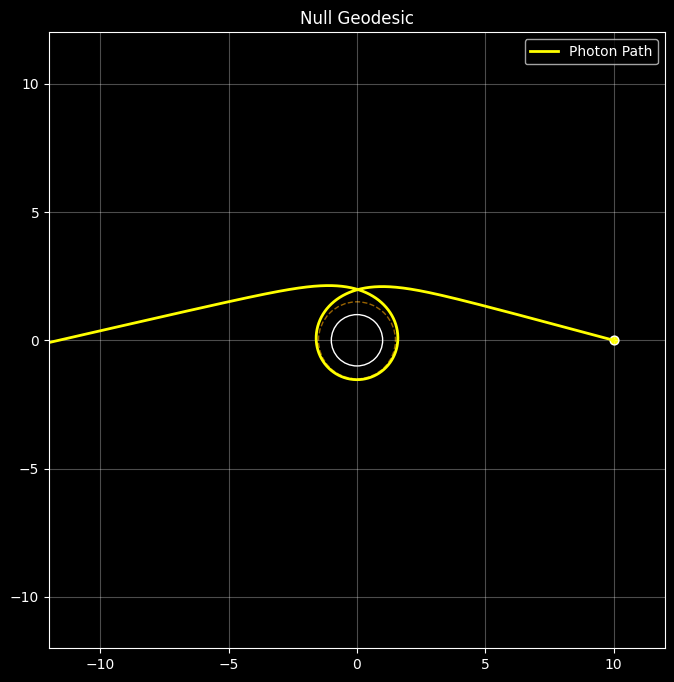

In [1269]:
plot_traj(df, label="Photon Path")
plt.title("Null Geodesic")
plt.show()

max dE: 1.0885403689542269e-11
max dL: 1.183053138025673e-11


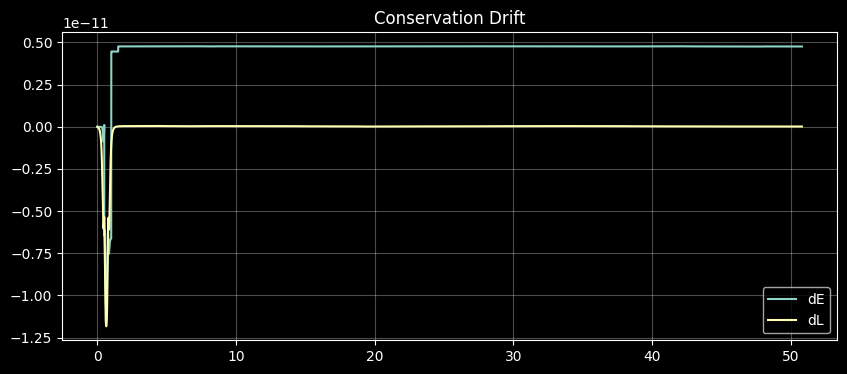

In [1270]:
plt.figure(figsize=(10,4))
print("max dE:", np.max(np.abs(df["dE"])))
print("max dL:", np.max(np.abs(df["dL"])))
assert np.max(np.abs(df["dE"])) < 1e-10
assert np.max(np.abs(df["dL"])) < 1e-10

plt.plot(df["lambda"], df["dE"], label="dE")
plt.plot(df["lambda"], df["dL"], label="dL")

plt.legend()
plt.title("Conservation Drift")
plt.grid(alpha=0.3)
plt.show()

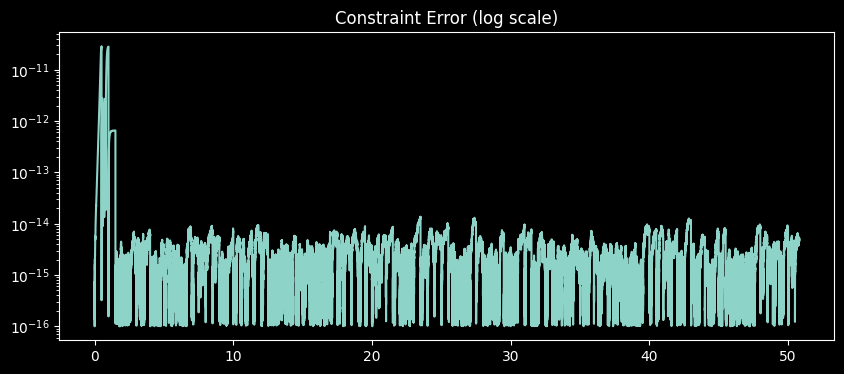

In [1271]:
plt.figure(figsize=(10,4))
plt.plot(df["lambda"], np.abs(df["H"]) + 1e-16)
plt.yscale("log")
plt.title("Constraint Error (log scale)")
plt.show()

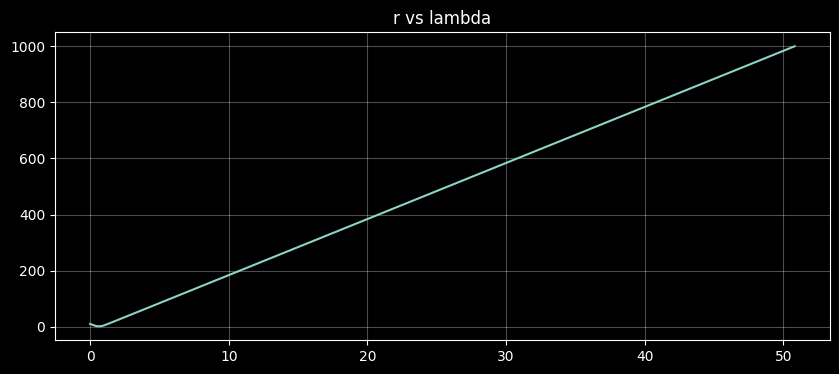

Minimum radius: 1.53502155884801


In [1272]:
plt.figure(figsize=(10,4))

plt.plot(df["lambda"], df["r"])
plt.title("r vs lambda")
plt.grid(alpha=0.3)

plt.show()

print("Minimum radius:", df["r"].min())

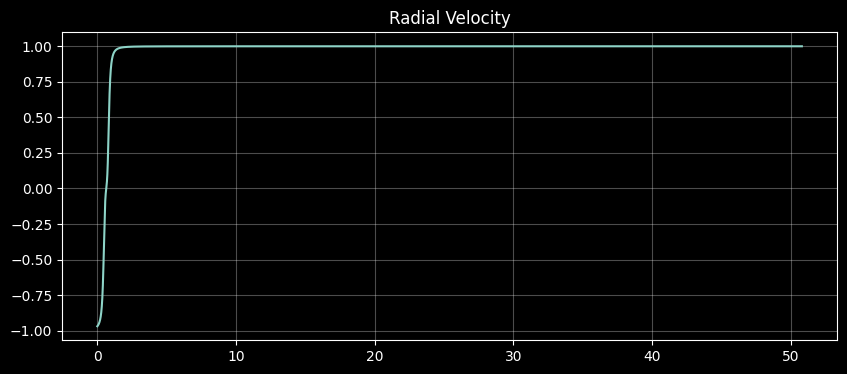

In [1273]:
plt.figure(figsize=(10,4))

plt.plot(df["lambda"], df["vr"])
plt.title("Radial Velocity")
plt.grid(alpha=0.3)

plt.show()

In [1274]:
phi_final = df["phi"].iloc[-1]
deflection = phi_final - np.pi

print("Final phi:", phi_final)
print("Deflection angle:", deflection)

Final phi: 9.647804257573316
Deflection angle: 6.506211603983523


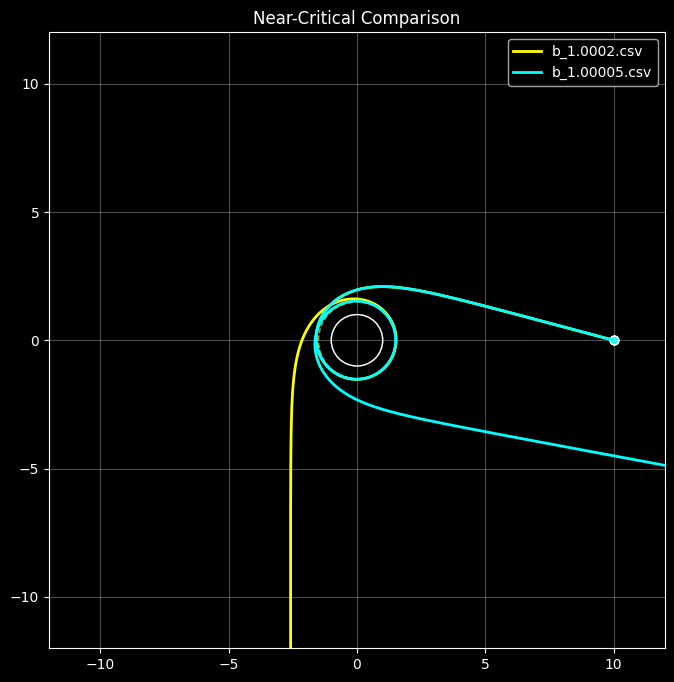

In [1275]:
files = [
    "b_1.0002.csv",
    "b_1.00005.csv"
]

fig, ax = plt.subplots(figsize=(8,8))

colors = ["yellow", "cyan"]

for f, c in zip(files, colors):
    df = load(f)
    plot_traj(df, ax=ax, label=f, color=c)

plt.title("Near-Critical Comparison")
plt.show()

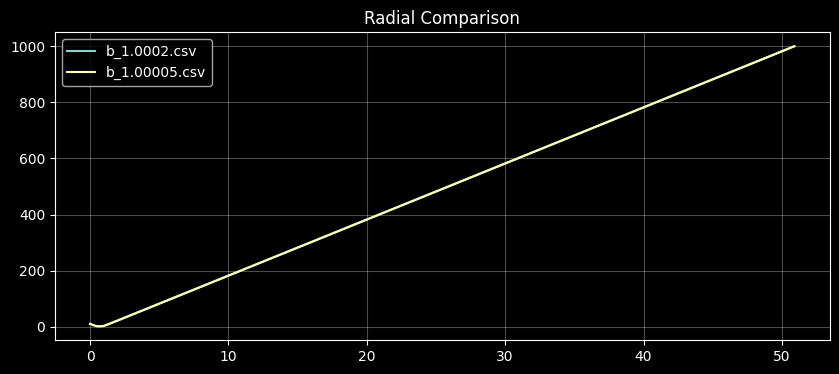

In [1276]:
plt.figure(figsize=(10,4))

for f in files:
    df = load(f)
    plt.plot(df["lambda"], df["r"], label=f)

plt.legend()
plt.title("Radial Comparison")
plt.grid(alpha=0.3)

plt.show()

In [1277]:
def summarize(df):
    return {
        "min_r": df["r"].min(),
        "max_H": np.abs(df["H"]).max(),
        "max_dE": np.abs(df["dE"]).max(),
        "max_dL": np.abs(df["dL"]).max()
    }

for f in files:
    df = load(f)
    print(f, summarize(df))

b_1.0002.csv {'min_r': np.float64(1.517589111644903), 'max_H': np.float64(2.8793190054443578e-11), 'max_dE': np.float64(1.133726446056471e-11), 'max_dL': np.float64(1.2171372435461689e-11)}
b_1.00005.csv {'min_r': np.float64(1.508727176348811), 'max_H': np.float64(2.8805402507714458e-11), 'max_dE': np.float64(1.1469936112007419e-11), 'max_dL': np.float64(1.226156445029163e-11)}


In [1278]:
results = []

files = [f for f in DATA_DIR.glob("*.csv") if "null_dt_" in f.name]

for f in files:
    df = load(f)
    
    phi_final = df["phi"].iloc[-1]
    deflection = phi_final - np.pi
    
    results.append({
        "file": f,
        "min_r": df["r"].min(),
        "max_H": np.abs(df["H"]).max(),
        "max_dE": np.abs(df["dE"]).max(),
        "max_dL": np.abs(df["dL"]).max(),
        "deflection": deflection
    })

pd.DataFrame(results)

,file,min_r,max_H,max_dE,max_dL,deflection
0,..\data\null_dt_0.000250.csv,1.503e+00,8.882e-16,1.315e-11,1.230e-11,1.154e+01
1,..\data\null_dt_0.000500.csv,1.503e+00,2.925e-11,1.151e-11,1.229e-11,1.154e+01
2,..\data\null_dt_0.001000.csv,1.503e+00,8.882e-16,1.315e-11,1.230e-11,1.154e+01
3,..\data\null_dt_0.002500.csv,1.503e+00,2.925e-11,1.151e-11,1.229e-11,1.154e+01
4,..\data\null_dt_0.005000.csv,1.503e+00,2.925e-11,1.151e-11,1.229e-11,1.154e+01
5,..\data\null_dt_0.010000.csv,1.503e+00,2.925e-11,1.151e-11,1.229e-11,1.154e+01
6,..\data\null_dt_0.020000.csv,1.503e+00,2.925e-11,1.151e-11,1.229e-11,1.154e+01


In [1279]:
from scipy.interpolate import interp1d

pairs = [
    ("null_dt_0.020000.csv", "null_dt_0.010000.csv"),
    ("null_dt_0.010000.csv", "null_dt_0.005000.csv"),
    ("null_dt_0.005000.csv", "null_dt_0.002500.csv"),
]

errors = []
dts = []

for f in files:
    df = load(str(f))
    dt = float(f.name.split("_")[-1].replace(".csv",""))

    # state at step 0 and 1
    r0 = df["r"].values[0]
    r1 = df["r"].values[1]

    vr0 = df["vr"].values[0]

    # finite difference derivative
    dr_num = (r1 - r0) / dt

    # actual derivative (from velocity)
    dr_true = vr0

    err = abs(dr_num - dr_true)

    errors.append(err)
    dts.append(dt)

dts = np.array(dts)
errors = np.array(errors)

idx = np.argsort(dts)
dts = dts[idx]
errors = errors[idx]

print("dts:", dts)
print("errors:", errors)

dts: [0.00025 0.0005  0.001   0.0025  0.005   0.01    0.02   ]
errors: [3.7795654559559281e+01 1.8413252880822558e+01 8.7220520414541927e+00
 2.9073315378331750e+00 9.6909136995950229e-01 2.8713977334060559e-05
 4.8458875594575224e-01]


In [1280]:
# pick ONLY coarse dt region
mask = dts >= 0.0025

log_dt = np.log(dts[mask])
log_err = np.log(errors[mask])

slope = np.polyfit(log_dt, log_err, 1)[0]
print("slope:", slope)

slope: -2.2797180185836656


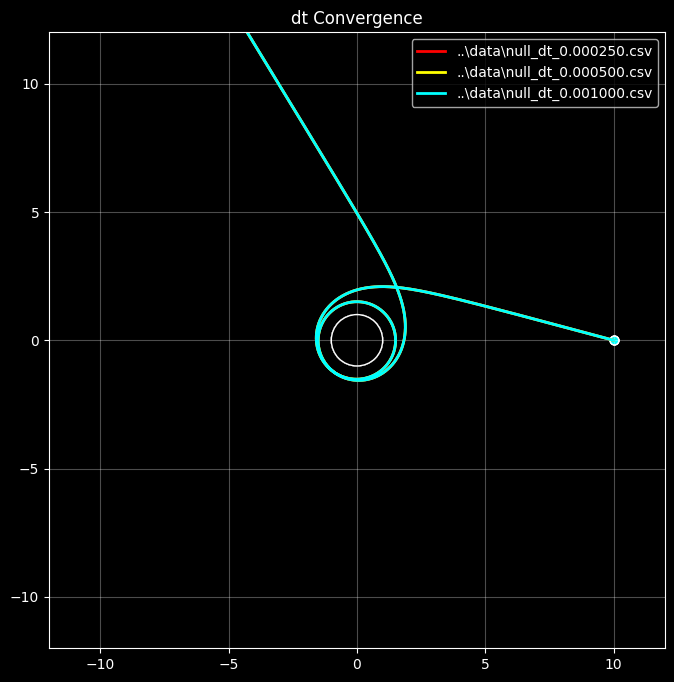

In [1281]:
fig, ax = plt.subplots(figsize=(8,8))

colors = ["red", "yellow", "cyan"]

for f, c in zip(files, colors):
    df = load(f)
    plot_traj(df, ax=ax, label=f, color=c)

plt.title("dt Convergence")
plt.show()

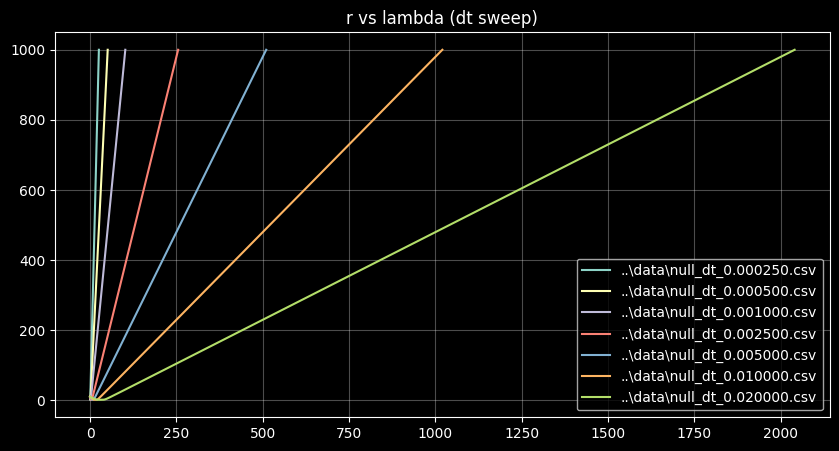

In [1282]:
plt.figure(figsize=(10,5))

for f in files:
    df = load(f)
    plt.plot(df["lambda"], df["r"], label=f)

plt.legend()
plt.title("r vs lambda (dt sweep)")
plt.grid(alpha=0.3)
plt.show()

In [1283]:
results = []

for f in files:
    df = load(f)
    results.append({
        "file": f,
        "min_r": df["r"].min(),
        "final_phi": df["phi"].iloc[-1]
    })

pd.DataFrame(results)

,file,min_r,final_phi
0,..\data\null_dt_0.000250.csv,1.503e+00,1.468e+01
1,..\data\null_dt_0.000500.csv,1.503e+00,1.468e+01
2,..\data\null_dt_0.001000.csv,1.503e+00,1.468e+01
3,..\data\null_dt_0.002500.csv,1.503e+00,1.468e+01
4,..\data\null_dt_0.005000.csv,1.503e+00,1.468e+01
5,..\data\null_dt_0.010000.csv,1.503e+00,1.468e+01
6,..\data\null_dt_0.020000.csv,1.503e+00,1.468e+01


In [1284]:
def deflection(df):
    return df["phi"].iloc[-1] - df["phi"].iloc[0] - np.pi
for f in files:
    df = load(f)
    print(f, deflection(df))

..\data\null_dt_0.000250.csv 11.540677273330267
..\data\null_dt_0.000500.csv 11.540677725429516
..\data\null_dt_0.001000.csv 11.540677273330267
..\data\null_dt_0.002500.csv 11.540677725429516
..\data\null_dt_0.005000.csv 11.540677725429516
..\data\null_dt_0.010000.csv 11.540677725429516
..\data\null_dt_0.020000.csv 11.540677725429516


In [1285]:
dts = []
phis = []

for f in files:
    df = load(str(f))

    dt = float(f.name.split("_")[-1].replace(".csv",""))

    dts.append(dt)
    phis.append(deflection(df))
    
dts = np.array(dts)
phis = np.array(phis)

# sort
idx = np.argsort(dts)
dts = dts[idx]
phis = phis[idx]

print("dts:", dts)
print("deflections:", phis)

dts: [0.00025 0.0005  0.001   0.0025  0.005   0.01    0.02   ]
deflections: [11.540677273330267 11.540677725429516 11.540677273330267
 11.540677725429516 11.540677725429516 11.540677725429516
 11.540677725429516]


errors: [0.0000000000000000e+00 4.5209924870448503e-07 0.0000000000000000e+00
 4.5209924870448503e-07 4.5209924870448503e-07 4.5209924870448503e-07
 4.5209924870448503e-07]


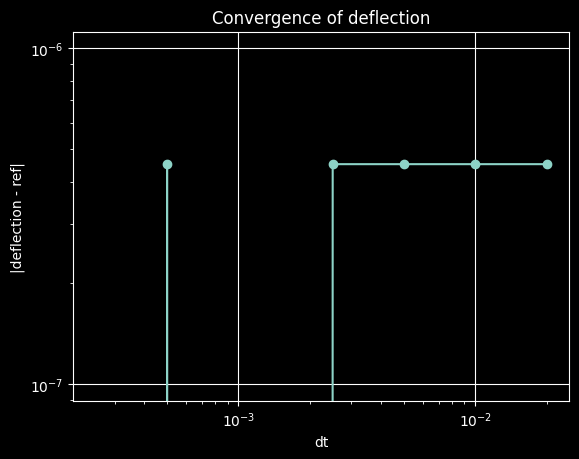

In [1286]:
ref = phis[0]
errors = np.abs(phis - ref)

print("errors:", errors)

plt.figure()
plt.plot(dts, errors, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt")
plt.ylabel("|deflection - ref|")
plt.title("Convergence of deflection")
plt.grid(True)
plt.show()

assert np.max(errors) < 1e-6

b_vals: [2.598096 2.598126 2.598176 2.598276 2.598576 2.599076 2.600076 2.603076
 2.608076]
deflections: [11.109165265033017 10.192918050882566  9.499839385857207
  8.806821876160006  7.890893408622757  7.198308547531187
  6.506211603983523  5.592802293599458  4.904037525932134]


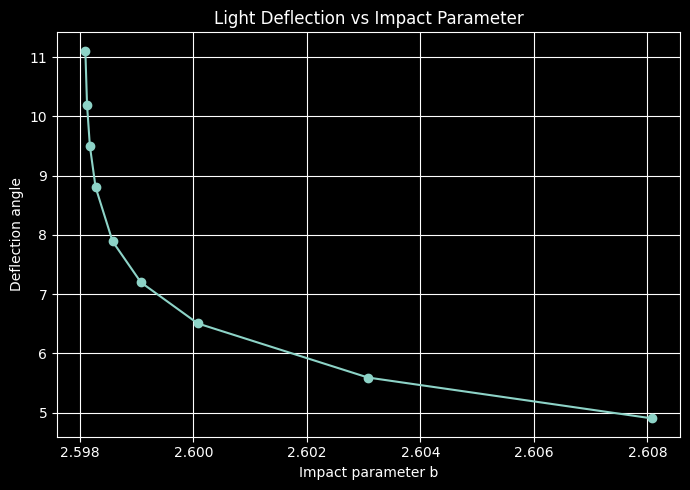


Data points:
b = 2.598096  -> deflection = 11.109165
b = 2.598126  -> deflection = 10.192918
b = 2.598176  -> deflection = 9.499839
b = 2.598276  -> deflection = 8.806822
b = 2.598576  -> deflection = 7.890893
b = 2.599076  -> deflection = 7.198309
b = 2.600076  -> deflection = 6.506212
b = 2.603076  -> deflection = 5.592802
b = 2.608076  -> deflection = 4.904038


In [1287]:
import re
def extract_b(filename):
    match = re.search(r"b_(\d+\.\d+)", filename)
    return float(match.group(1)) if match else None

def deflection(df):
    return df["phi"].iloc[-1] - df["phi"].iloc[0] - np.pi

def load(path):
    return pd.read_csv(path)

files = list(DATA_DIR.glob("null_b_*.csv"))

if len(files) == 0:
    raise RuntimeError("No null_b_*.csv files found. Check DATA_DIR.")

b_vals = []
deflections = []

def is_escaped(df):
    r = df["r"].values
    r_min = np.min(r)
    return df["r"].iloc[-1] > 50   # escaped far away # not captured

for f in files:
    b = extract_b(f.name)
    df = load(f)

    if not is_escaped(df):
        continue  # skip captured photons

    b_vals.append(b)
    deflections.append(deflection(df))

b_vals = np.array(b_vals)
deflections = np.array(deflections)

idx = np.argsort(b_vals)
b_vals = b_vals[idx]
deflections = deflections[idx]

print("b_vals:", b_vals)
print("deflections:", deflections)

plt.figure(figsize=(7,5))
plt.plot(b_vals, deflections, marker='o')

plt.xlabel("Impact parameter b")
plt.ylabel("Deflection angle")
plt.title("Light Deflection vs Impact Parameter")

plt.grid(True)
plt.tight_layout()
plt.show()

print("\nData points:")
for b, d in zip(b_vals, deflections):
    print(f"b = {b:.6f}  -> deflection = {d:.6f}")

In [1288]:
for f in files:
    if "null_b_" in f.name:
        df = load(f)
        print(f.name, df["r"].iloc[-1])

null_b_2.597076.csv 0.9962055903367972
null_b_2.597576.csv 0.9989347636504392
null_b_2.597976.csv 0.995099704504307
null_b_2.598096.csv 1000.003955425444
null_b_2.598126.csv 1000.007387440532
null_b_2.598176.csv 1000.007517546152
null_b_2.598276.csv 1000.00751646692
null_b_2.598576.csv 1000.000273833244
null_b_2.599076.csv 1000.009389398715
null_b_2.600076.csv 1000.007555732641
null_b_2.603076.csv 1000.005524194692
null_b_2.608076.csv 1000.007756707804


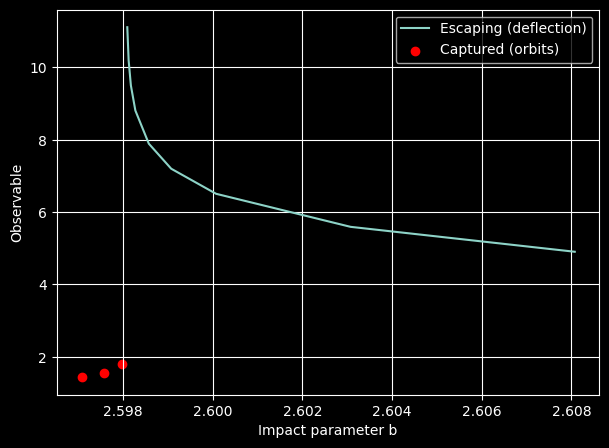

In [1289]:
b_escape, defl_escape = [], []
b_capture, orbits_capture = [], []

for f in files:
    if "null_b_" in f.name:
        df = load(f)
        b = extract_b(f.name)

        if df["r"].iloc[-1] > 50:
            b_escape.append(b)
            defl_escape.append(deflection(df))
        else:
            b_capture.append(b)
            orbits_capture.append(df["phi"].iloc[-1] / (2*np.pi))

plt.figure(figsize=(7,5))

plt.plot(b_escape, defl_escape, label="Escaping (deflection)")
plt.scatter(b_capture, orbits_capture, color='red', label="Captured (orbits)")

plt.xlabel("Impact parameter b")
plt.ylabel("Observable")
plt.legend()
plt.grid()
plt.show()

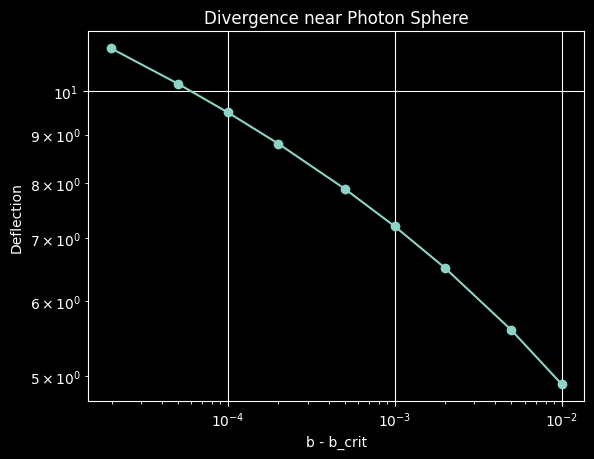

In [1290]:
b_crit = (3*np.sqrt(3)/2) * rs

delta_b = b_escape - b_crit
log_delta = np.log(delta_b)
log_defl = np.log(defl_escape)

slope = np.polyfit(log_delta, log_defl, 1)[0]

assert slope < 0   # should diverge

plt.plot(delta_b, defl_escape, marker='o')
plt.xscale("log")
plt.yscale("log")

plt.xlabel("b - b_crit")
plt.ylabel("Deflection")
plt.title("Divergence near Photon Sphere")
plt.grid()
plt.show()

log-log slope: -0.12311569631598679


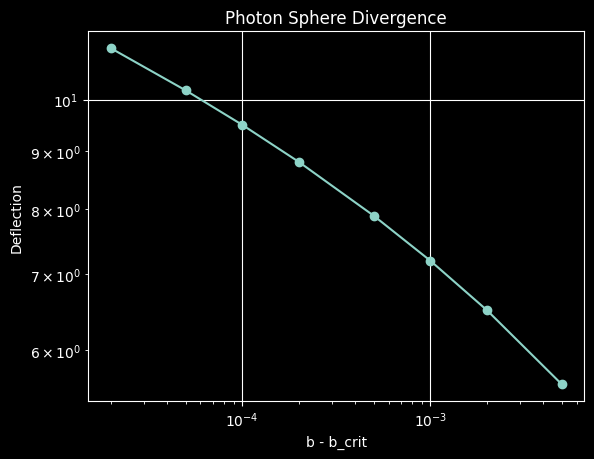

In [1291]:
b_crit = 2.598076

b_escape = np.array(b_escape)
defl_escape = np.array(defl_escape)

# sort
idx = np.argsort(b_escape)
b_escape = b_escape[idx]
defl_escape = defl_escape[idx]

delta_b = b_escape - b_crit

# 🔴 KEEP ONLY near-critical points
mask = (delta_b > 0) & (delta_b < 0.01)

delta_b = delta_b[mask]
defl_escape = defl_escape[mask]

log_db = np.log(delta_b)
log_defl = np.log(defl_escape)

slope = np.polyfit(log_db, log_defl, 1)[0]
print("log-log slope:", slope)

plt.figure()
plt.plot(delta_b, defl_escape, marker='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("b - b_crit")
plt.ylabel("Deflection")
plt.title("Photon Sphere Divergence")
plt.grid()
plt.show()

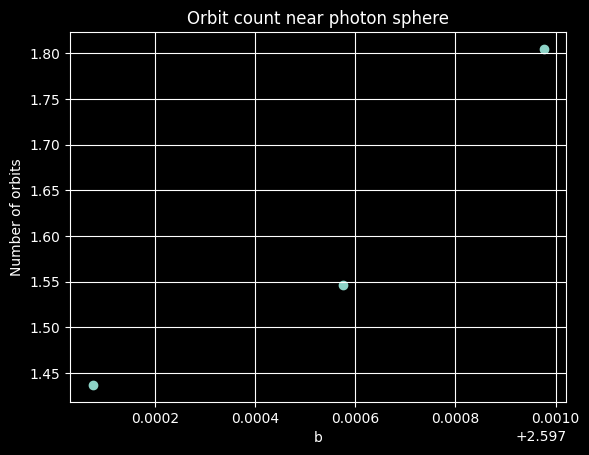

In [1292]:
plt.figure()
plt.scatter(b_capture, orbits_capture)

plt.xlabel("b")
plt.ylabel("Number of orbits")
plt.title("Orbit count near photon sphere")

plt.grid(True)
plt.show()

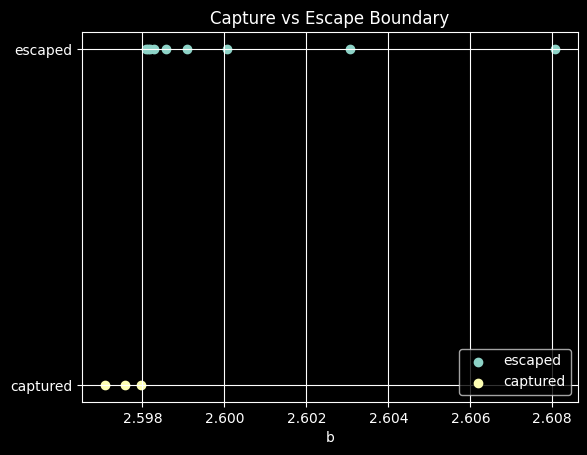

In [1293]:
escaped = []
captured = []

for f in files:
    df = load(str(f))
    b = extract_b(f.name)

    if df["r"].iloc[-1] > 50:
        escaped.append(b)
    else:
        captured.append(b)

plt.figure()
plt.scatter(escaped, [1]*len(escaped), label="escaped")
plt.scatter(captured, [0]*len(captured), label="captured")

plt.xlabel("b")
plt.yticks([0,1], ["captured", "escaped"])
plt.title("Capture vs Escape Boundary")

plt.legend()
plt.grid()
plt.show()

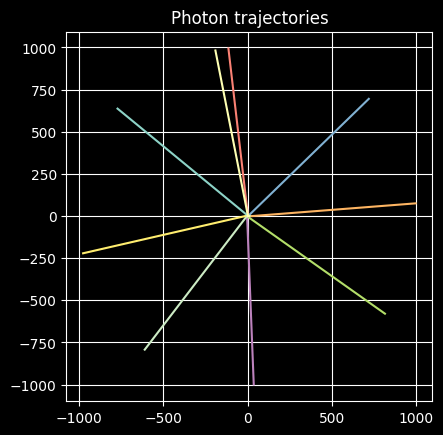

In [1294]:
plt.figure()

for f in files:
    df = load(str(f))
    r = df["r"].values
    phi = df["phi"].values

    x = r * np.cos(phi)
    y = r * np.sin(phi)

    plt.plot(x, y)

plt.gca().set_aspect('equal')
plt.title("Photon trajectories")
plt.grid()
plt.show()